In [2]:
import numpy as np
import pandas as pd
import glob
import os
from settings import RAW_DIR

In [4]:

def load_year(year:str) -> pd.DataFrame:
    files = sorted((RAW_DIR / year).glob('*.csv'))
    print(f'{year}: found {len(files)} files')

    for f in files:
        print('-', os.path.basename(f))

    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df['source_file'] = os.path.basename(f)
        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True)
    print(f'{year} merged shape: {merged.shape}')
    return merged

In [5]:
df_2025 = load_year('2025')

2025: found 12 files
- 202501-divvy-tripdata.csv
- 202502-divvy-tripdata.csv
- 202503-divvy-tripdata.csv
- 202504-divvy-tripdata.csv
- 202505-divvy-tripdata.csv
- 202506-divvy-tripdata.csv
- 202507-divvy-tripdata.csv
- 202508-divvy-tripdata.csv
- 202509-divvy-tripdata.csv
- 202510-divvy-tripdata.csv
- 202511-divvy-tripdata.csv
- 202512-divvy-tripdata.csv


2025 merged shape: (5552994, 14)


In [6]:
df_2026 = load_year('2026')

2026: found 7 files
- 202601-divvy-tripdata.csv
- 202602-divvy-tripdata.csv
- 202603-divvy-tripdata.csv
- 202604-divvy-tripdata.csv
- 202605-divvy-tripdata.csv
- 202606-divvy-tripdata.csv
- 202607-divvy-tripdata.csv
2026 merged shape: (3389831, 14)


In [7]:
df_2025.columns.equals(df_2026.columns)

True

In [8]:
set(df_2025.columns) == set(df_2026.columns)

True

In [9]:
df_2025.dtypes

ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
source_file               str
dtype: object

In [10]:
df_2026.dtypes

ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
source_file               str
dtype: object

In [11]:
df_2025.columns.equals(df_2026.columns)

True

In [12]:
df_2025.isna().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1184673
start_station_id      1184673
end_station_name      1243305
end_station_id        1243305
start_lat                   0
start_lng                   0
end_lat                  5535
end_lng                  5535
member_casual               0
source_file                 0
dtype: int64

In [13]:
df_2025.isna().mean().sort_values(ascending=False) * 100

end_station_id        22.389813
end_station_name      22.389813
start_station_name    21.333951
start_station_id      21.333951
end_lat                0.099676
end_lng                0.099676
started_at             0.000000
ended_at               0.000000
ride_id                0.000000
rideable_type          0.000000
start_lng              0.000000
start_lat              0.000000
member_casual          0.000000
source_file            0.000000
dtype: float64

In [14]:
df_2026.isna().sum()

ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_station_name    691633
start_station_id      691633
end_station_name      722127
end_station_id        722127
start_lat                  0
start_lng                  0
end_lat                 3059
end_lng                 3059
member_casual              0
source_file                0
dtype: int64

In [15]:
df_2026.isna().mean().sort_values(ascending=False) * 100

end_station_id        21.302743
end_station_name      21.302743
start_station_name    20.403171
start_station_id      20.403171
end_lat                0.090240
end_lng                0.090240
started_at             0.000000
ended_at               0.000000
ride_id                0.000000
rideable_type          0.000000
start_lng              0.000000
start_lat              0.000000
member_casual          0.000000
source_file            0.000000
dtype: float64

In [16]:
df_2025.duplicated().sum()

np.int64(0)

In [17]:
df_2026.duplicated().sum()

np.int64(0)

In [18]:
df_2025.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member,202501-divvy-tripdata.csv
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member,202501-divvy-tripdata.csv
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member,202501-divvy-tripdata.csv
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,202501-divvy-tripdata.csv
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,202501-divvy-tripdata.csv


In [19]:
df_2025.tail()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file
5552989,53202484E8371237,electric_bike,2025-12-19 13:43:41.793,2025-12-19 13:54:07.779,Sheffield Ave & Kingsbury St,CHI02023,Halsted St & Melrose St,CHI02162,41.910522,-87.653106,41.941120,-87.649070,member,202512-divvy-tripdata.csv
5552990,3582BF76707AB2ED,classic_bike,2025-12-27 12:43:48.446,2025-12-27 12:52:45.141,Larrabee St & Webster Ave,CHI00454,Halsted St & Melrose St,CHI02162,41.921822,-87.644140,41.941120,-87.649070,member,202512-divvy-tripdata.csv
5552991,B12D92DF229EFA41,electric_bike,2025-12-20 01:12:39.053,2025-12-20 01:18:55.928,Clarendon Ave & Junior Ter,CHI00395,Halsted St & Melrose St,CHI02162,41.961004,-87.649603,41.941120,-87.649070,casual,202512-divvy-tripdata.csv
5552992,04D5C6C11909ECAE,electric_bike,2025-12-08 16:46:37.496,2025-12-08 16:58:32.762,Lincoln Ave & Waveland Ave,CHI00446,Halsted St & Wrightwood Ave,CHI00504,41.948797,-87.675278,41.929143,-87.649077,member,202512-divvy-tripdata.csv
5552993,D2CF23B6D79232B6,classic_bike,2025-12-20 13:08:27.589,2025-12-20 13:13:54.815,Larrabee St & Webster Ave,CHI00454,Halsted St & Wrightwood Ave,CHI00504,41.921822,-87.644140,41.929143,-87.649077,member,202512-divvy-tripdata.csv


In [20]:
df_2025.sample(10)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file
3410647,E99E20EBCBFD5E69,electric_bike,2025-08-03 12:40:43.890,2025-08-03 13:08:41.466,Wabash Ave & Wacker Pl,CHI00416,NaN,NaN,41.886875,-87.626030,41.880000,-87.630000,casual,202508-divvy-tripdata.csv
4144306,E5C206594702D650,electric_bike,2025-09-14 17:24:36.827,2025-09-14 17:39:04.933,NaN,NaN,Public Rack - California Ave & Devon Ave - NE,CHI00894,42.010000,-87.670000,41.998260,-87.699481,casual,202509-divvy-tripdata.csv
5080066,2250B9BF6F6AD58F,classic_bike,2025-11-18 19:54:57.992,2025-11-18 20:02:03.111,Michigan Ave & Washington St,CHI01677,Michigan Ave & Ida B Wells Dr,CHI00250,41.883984,-87.624684,41.876203,-87.624464,member,202511-divvy-tripdata.csv
643496,99E79834187D5C68,classic_bike,2025-04-07 08:55:40.371,2025-04-07 09:29:00.118,Artesian Ave & Hubbard St,15664,Canal St & Jackson Blvd,13138,41.889500,-87.688257,41.878125,-87.639968,member,202504-divvy-tripdata.csv
2138967,9B6949CA8A91B147,electric_bike,2025-06-19 12:13:18.096,2025-06-19 12:21:05.988,NaN,NaN,NaN,NaN,41.950000,-87.640000,41.940000,-87.640000,casual,202506-divvy-tripdata.csv
3130401,556D15F2B212574A,electric_bike,2025-08-17 12:47:18.215,2025-08-17 13:28:32.225,Griffin Museum of Science and Industry,CHI00574,NaN,NaN,41.791728,-87.583945,41.900000,-87.620000,member,202508-divvy-tripdata.csv
2904276,39E9BC1EE5808BA0,electric_bike,2025-07-11 19:27:04.551,2025-07-11 19:36:21.950,Ashland Ave & Division St,CHI00244,NaN,NaN,41.903010,-87.668770,41.900000,-87.680000,member,202507-divvy-tripdata.csv
4128441,3949BE165F74886F,electric_bike,2025-09-10 07:34:55.824,2025-09-10 07:40:24.335,Milwaukee Ave & Grand Ave,CHI01750,Wacker Dr & Washington St,CHI01787,41.891582,-87.648303,41.883143,-87.637242,casual,202509-divvy-tripdata.csv
1678957,D1ABBF6A67DEBC0A,electric_bike,2025-06-10 19:51:23.225,2025-06-10 19:57:46.246,Clifton Ave & Armitage Ave,CHI00421,Wells St & Concord Ln,CHI00396,41.918216,-87.656936,41.912133,-87.634656,casual,202506-divvy-tripdata.csv
1535594,82148F58D98A23EC,classic_bike,2025-06-29 15:01:36.363,2025-06-29 15:12:03.002,DuSable Lake Shore Dr & Wellington Ave,CHI00255,Pine Grove Ave & Waveland Ave,CHI00354,41.936688,-87.636829,41.949473,-87.646453,member,202506-divvy-tripdata.csv


In [21]:
df_2025.info()

<class 'pandas.DataFrame'>
RangeIndex: 5552994 entries, 0 to 5552993
Data columns (total 14 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
 13  source_file         str    
dtypes: float64(4), str(10)
memory usage: 593.1 MB


In [22]:
df_2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 3389831 entries, 0 to 3389830
Data columns (total 14 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
 13  source_file         str    
dtypes: float64(4), str(10)
memory usage: 362.1 MB


In [23]:
df_2026.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member,202601-divvy-tripdata.csv
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual,202601-divvy-tripdata.csv
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member,202601-divvy-tripdata.csv
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member,202601-divvy-tripdata.csv
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member,202601-divvy-tripdata.csv


In [24]:
df_2026.tail()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file
3389826,D5CD1C4E7B56E481,electric_bike,2026-07-05 12:29:45.640,2026-07-05 12:35:02.419,May St & Taylor St,CHI00322,NaN,NaN,41.869380,-87.655500,41.87,-87.67,member,202607-divvy-tripdata.csv
3389827,DAF0BD6AFE41DFE7,electric_bike,2026-07-31 16:38:46.825,2026-07-31 16:51:12.350,Wells St & Randolph St,CHI00266,NaN,NaN,41.884295,-87.633963,41.88,-87.64,casual,202607-divvy-tripdata.csv
3389828,CAE5402C8F0ED873,electric_bike,2026-07-29 09:51:38.810,2026-07-29 09:59:39.356,Sheffield Ave & Kingsbury St,CHI02023,NaN,NaN,41.910522,-87.653106,41.89,-87.64,member,202607-divvy-tripdata.csv
3389829,8883CB153A66EEAD,electric_bike,2026-07-05 16:42:01.513,2026-07-05 21:38:45.693,Lincoln Ave & Waveland Ave,CHI00446,NaN,NaN,41.948797,-87.675278,41.96,-87.71,member,202607-divvy-tripdata.csv
3389830,57C5C52223EC849F,electric_bike,2026-07-05 12:47:16.205,2026-07-05 12:55:16.578,Sheffield Ave & Kingsbury St,CHI02023,NaN,NaN,41.910522,-87.653106,41.89,-87.64,member,202607-divvy-tripdata.csv


In [25]:
df_2025['member_casual'].value_counts()

member_casual
member    3553497
casual    1999497
Name: count, dtype: int64

In [26]:
df_2025['rideable_type'].value_counts()

rideable_type
electric_bike    3604953
classic_bike     1948041
Name: count, dtype: int64

In [27]:
df_2026['member_casual'].value_counts()

member_casual
member    2193216
casual    1196615
Name: count, dtype: int64

In [28]:
df_2026['rideable_type'].value_counts()

rideable_type
electric_bike    2389154
classic_bike     1000677
Name: count, dtype: int64

In [29]:
df_2025['started_at'] = pd.to_datetime(df_2025['started_at'])
df_2025['ended_at'] = pd.to_datetime(df_2025['ended_at'])

df_2026['started_at'] = pd.to_datetime(df_2026['started_at'])
df_2026['ended_at'] = pd.to_datetime(df_2026['ended_at'])

In [30]:
df_2026.dtypes
df_2025.dtypes

ride_id                          str
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id                 str
end_station_name                 str
end_station_id                   str
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
source_file                      str
dtype: object

In [31]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [32]:
(df_2025['ended_at'] < df_2025['started_at']).sum()

np.int64(29)

In [33]:
(df_2026['ended_at'] < df_2026['started_at']).sum()

np.int64(0)

In [34]:
df_2026['ride_duration'] = (
    df_2026['ended_at'] - df_2026['started_at']
).dt.total_seconds()/60

In [35]:
df_2026.ride_duration.describe()

count   3389831.00
mean         15.34
std          51.38
min           0.00
25%           5.29
50%           9.26
75%          16.21
max        1559.95
Name: ride_duration, dtype: float64

In [36]:
df_2025['ride_duration'] = (
    df_2025['ended_at'] - df_2026['started_at']
).dt.total_seconds()/60

ups.... 26

In [37]:
df_2025.ride_duration.describe()

count   3389831.00
mean    -507282.31
std       27757.83
min     -607741.90
25%     -528489.48
50%     -509030.94
75%     -486446.62
max     -435927.25
Name: ride_duration, dtype: float64

In [38]:
df_2026[df_2026['ride_duration'] < 0]

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file,ride_duration


In [39]:
bad_2025 = df_2025[df_2025['ended_at'] < df_2025['started_at']]
bad_2025[['started_at', 'ended_at']].head(50)

,started_at,ended_at
5080953,2025-11-02 01:52:37.475,2025-11-02 01:13:24.728
5082501,2025-11-02 01:50:39.702,2025-11-02 01:14:04.164
5084495,2025-11-02 01:57:57.512,2025-11-02 01:33:52.225
5099391,2025-11-02 01:55:34.399,2025-11-02 01:21:31.873
5107759,2025-11-02 01:17:57.001,2025-11-02 01:05:27.752
5152344,2025-11-02 01:55:38.177,2025-11-02 01:04:35.315
5177897,2025-11-02 01:51:31.704,2025-11-02 01:05:47.339
5183355,2025-11-02 01:59:07.835,2025-11-02 01:05:19.214
5203278,2025-11-02 01:59:40.156,2025-11-02 01:08:51.303
5213096,2025-11-02 01:49:48.360,2025-11-02 01:02:40.976


In [40]:
bad_2025['started_at'].dt.date.value_counts()

started_at
2025-11-02    29
Name: count, dtype: int64

In [41]:
bad_2025['ride_duration'].describe()

count   0.00
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: ride_duration, dtype: float64

In [42]:
(df_2025['ended_at'] < df_2025['started_at']).sum()

np.int64(29)

In [43]:
df_2025[['started_at', 'ended_at', 'ride_duration']].head()

,started_at,ended_at,ride_duration
0,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,-539495.28
1,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,-531276.52
2,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,-531207.51
3,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,-530369.75
4,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,-517532.39


In [44]:
df_2025['ride_duration'].isna().sum()

np.int64(2163163)

In [45]:
df_2025.loc[
    df_2025['ride_duration'].isna(),
    ['started_at', 'ended_at']
].isna().sum()

started_at    0
ended_at      0
dtype: int64

In [46]:
df_2025[
    df_2025['ride_duration'].isna()
][['started_at', 'ended_at']].tail(10)

,started_at,ended_at
5552984,2025-12-08 15:44:56.489,2025-12-08 15:52:22.361
5552985,2025-12-02 16:46:41.931,2025-12-02 16:53:42.631
5552986,2025-12-25 12:05:30.395,2025-12-25 12:08:39.725
5552987,2025-12-28 02:18:09.691,2025-12-28 02:22:06.189
5552988,2025-12-12 12:05:29.252,2025-12-12 12:11:03.737
5552989,2025-12-19 13:43:41.793,2025-12-19 13:54:07.779
5552990,2025-12-27 12:43:48.446,2025-12-27 12:52:45.141
5552991,2025-12-20 01:12:39.053,2025-12-20 01:18:55.928
5552992,2025-12-08 16:46:37.496,2025-12-08 16:58:32.762
5552993,2025-12-20 13:08:27.589,2025-12-20 13:13:54.815


In [47]:
missing_duration = df_2025['ride_duration'].isna()

print('Missing ride duration:', missing_duration.sum())
print('Missing started_at:', df_2025.loc[missing_duration, 'started_at'].isna().sum())
print('Missing ended_at:', df_2025.loc[missing_duration, 'ended_at'].isna().sum())

Missing ride duration: 2163163
Missing started_at: 0
Missing ended_at: 0


In [48]:
df_2025.loc[
    df_2025['ride_duration'].isna(),
    'source_file'
].value_counts()

source_file
202509-divvy-tripdata.csv    714759
202510-divvy-tripdata.csv    646039
202511-divvy-tripdata.csv    356628
202508-divvy-tripdata.csv    305203
202512-divvy-tripdata.csv    140534
Name: count, dtype: int64

In [49]:
df_2025[['started_at', 'ended_at', 'ride_duration']].dtypes

started_at       datetime64[us]
ended_at         datetime64[us]
ride_duration           float64
dtype: object

In [50]:
df_2025.loc[
    df_2025['ride_duration'].isna(),
    ['started_at', 'ended_at']
].head()

,started_at,ended_at
3389831,2025-08-15 20:57:41.899,2025-08-15 21:08:33.989
3389832,2025-08-06 09:49:16.227,2025-08-06 09:53:16.631
3389833,2025-08-13 14:55:31.997,2025-08-13 15:12:34.934
3389834,2025-08-15 12:36:20.232,2025-08-15 12:48:34.054
3389835,2025-08-22 10:07:00.106,2025-08-22 10:24:09.917


In [51]:
df_2025.loc[3389831, 'ended_at'] - df_2025.loc[3389831, 'started_at']

Timedelta('0 days 00:10:52.090000')

In [52]:
df_2025.loc[3389831, 'ride_duration']

np.float64(nan)

In [53]:
df_2025.loc[3389831, ['started_at', 'ended_at']]

started_at   2025-08-15 20:57:41.899
ended_at     2025-08-15 21:08:33.989
Name: 3389831, dtype: datetime64[us]

In [54]:
(df_2025.loc[3389831, 'ended_at'] - df_2025.loc[3389831, 'started_at']).total_seconds()/60

10.868166666666667

In [55]:
df_2025['ride_duration'].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99, .999]
)

count   3389831.00
mean    -507282.31
std       27757.83
min     -607741.90
1%      -560802.40
5%      -550501.74
25%     -528489.48
50%     -509030.94
75%     -486446.62
95%     -459722.26
99%     -447673.81
99.9%   -440470.53
max     -435927.25
Name: ride_duration, dtype: float64

In [56]:
df_2025['ride_duration'] = (
    df_2025['ended_at']- df_2025['started_at']    
).dt.total_seconds() / 60


In [57]:
print("2025:", df_2025['ride_duration'].isna().sum())
print("2026:", df_2026['ride_duration'].isna().sum())

2025: 0
2026: 0


In [58]:
print("2025:", (df_2025['ride_duration'] < 0).sum())
print("2026:", (df_2026['ride_duration'] < 0).sum())

2025: 29
2026: 0


In [59]:
bad_2025.ride_duration.sum()

np.float64(0.0)

In [60]:
print(df_2025.dtypes.equals(df_2026.dtypes))

True


In [61]:
#checking 2025 both dates
dst_2025 = df_2025[
    df_2025['started_at'].dt.date.isin([
        pd.Timestamp('2025-03-09').date(),
        pd.Timestamp('2025-11-02').date()
    ])
]

dst_2025[['started_at', 'ended_at', 'ride_duration']].sort_values('started_at')

,started_at,ended_at,ride_duration
362056,2025-03-09 00:00:05.382,2025-03-09 00:06:09.456,6.07
336355,2025-03-09 00:00:19.052,2025-03-09 00:24:27.472,24.14
550261,2025-03-09 00:00:22.619,2025-03-09 00:03:56.887,3.57
397601,2025-03-09 00:00:54.221,2025-03-09 00:04:41.593,3.79
395434,2025-03-09 00:01:08.706,2025-03-09 00:06:20.739,5.20
...,...,...,...
5408122,2025-11-02 23:57:53.129,2025-11-03 00:02:00.427,4.12
5408120,2025-11-02 23:58:26.362,2025-11-03 00:02:02.597,3.60
5056410,2025-11-02 23:58:52.376,2025-11-03 00:07:46.496,8.90
5351839,2025-11-02 23:59:51.177,2025-11-03 00:08:24.420,8.55


In [62]:
dst_2025[
    dst_2025['started_at'].dt.hour.isin([1,2])
][['started_at','ended_at','ride_duration']]

,started_at,ended_at,ride_duration
293289,2025-03-09 01:53:28.816,2025-03-09 03:12:14.818,78.77
294562,2025-03-09 01:14:13.378,2025-03-09 01:25:30.075,11.28
295115,2025-03-09 01:36:46.543,2025-03-09 01:57:04.216,20.29
299178,2025-03-09 01:32:11.267,2025-03-09 01:34:46.812,2.59
300607,2025-03-09 01:08:16.508,2025-03-09 01:10:06.298,1.83
...,...,...,...
5408722,2025-11-02 02:18:00.202,2025-11-02 02:22:17.257,4.28
5409196,2025-11-02 01:11:58.637,2025-11-02 01:20:52.863,8.90
5411337,2025-11-02 01:27:38.396,2025-11-02 01:32:50.911,5.21
5412284,2025-11-02 01:19:31.028,2025-11-02 01:30:41.641,11.18


In [63]:
dst_fall_2025 = (
    (df_2025['started_at'].dt.date == pd.Timestamp('2025-11-02').date()) &
    (df_2025['ended_at'] < df_2025['started_at'])
)

In [64]:
dst_fall_2025.sum()

np.int64(29)

In [65]:
(df_2025.loc[dst_fall_2025, 'ride_duration'] < 0).sum()

np.int64(29)

In [66]:
df_2025.loc[
    dst_fall_2025,
    ['started_at','ended_at','ride_duration']
].head(30)

,started_at,ended_at,ride_duration
5080953,2025-11-02 01:52:37.475,2025-11-02 01:13:24.728,-39.21
5082501,2025-11-02 01:50:39.702,2025-11-02 01:14:04.164,-36.59
5084495,2025-11-02 01:57:57.512,2025-11-02 01:33:52.225,-24.09
5099391,2025-11-02 01:55:34.399,2025-11-02 01:21:31.873,-34.04
5107759,2025-11-02 01:17:57.001,2025-11-02 01:05:27.752,-12.49
5152344,2025-11-02 01:55:38.177,2025-11-02 01:04:35.315,-51.05
5177897,2025-11-02 01:51:31.704,2025-11-02 01:05:47.339,-45.74
5183355,2025-11-02 01:59:07.835,2025-11-02 01:05:19.214,-53.81
5203278,2025-11-02 01:59:40.156,2025-11-02 01:08:51.303,-50.81
5213096,2025-11-02 01:49:48.360,2025-11-02 01:02:40.976,-47.12


In [67]:
print("All Nov 2 rides:", (
    df_2025['started_at'].dt.date ==
    pd.Timestamp('2025-11-02').date()
).sum())

print("Negative durations:", (
    df_2025['ride_duration'] < 0
).sum())

print("DST fall mask:", dst_fall_2025.sum())

All Nov 2 rides: 13748
Negative durations: 29
DST fall mask: 29


In [68]:
#fallback duration
df_2025['ride_duration_raw'] = df_2025['ride_duration']

In [69]:
df_2025.loc[
    dst_fall_2025,
    ['started_at','ended_at','ride_duration']
].assign(
    corrected_duration=lambda x: x['ride_duration'] + 60
)

,started_at,ended_at,ride_duration,corrected_duration
5080953,2025-11-02 01:52:37.475,2025-11-02 01:13:24.728,-39.21,20.79
5082501,2025-11-02 01:50:39.702,2025-11-02 01:14:04.164,-36.59,23.41
5084495,2025-11-02 01:57:57.512,2025-11-02 01:33:52.225,-24.09,35.91
5099391,2025-11-02 01:55:34.399,2025-11-02 01:21:31.873,-34.04,25.96
5107759,2025-11-02 01:17:57.001,2025-11-02 01:05:27.752,-12.49,47.51
5152344,2025-11-02 01:55:38.177,2025-11-02 01:04:35.315,-51.05,8.95
5177897,2025-11-02 01:51:31.704,2025-11-02 01:05:47.339,-45.74,14.26
5183355,2025-11-02 01:59:07.835,2025-11-02 01:05:19.214,-53.81,6.19
5203278,2025-11-02 01:59:40.156,2025-11-02 01:08:51.303,-50.81,9.19
5213096,2025-11-02 01:49:48.360,2025-11-02 01:02:40.976,-47.12,12.88


In [70]:
df_2025.loc[dst_fall_2025,'ride_duration'] += 60

In [71]:
(df_2025['ride_duration']< 0).sum()

np.int64(0)

In [72]:
df_2025.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file,ride_duration,ride_duration_raw
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.88,-87.64,41.89,-87.62,member,202501-divvy-tripdata.csv,13.96,13.96
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.93,-87.65,41.94,-87.66,member,202501-divvy-tripdata.csv,5.07,5.07
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.95,-87.66,41.95,-87.65,member,202501-divvy-tripdata.csv,11.59,11.59
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.95,-87.66,41.94,-87.66,member,202501-divvy-tripdata.csv,3.57,3.57
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.95,-87.66,41.94,-87.66,member,202501-divvy-tripdata.csv,2.57,2.57


In [73]:
dst_spring_2025 = (
    (df_2025['started_at'].dt.date == pd.Timestamp('2025-03-09').date()) &
    (df_2025['started_at'].dt.hour == 1) &
    (df_2025['ended_at'].dt.hour == 3)
)

In [74]:
dst_spring_2025.sum()

np.int64(29)

In [75]:
df_2025.loc[
    dst_spring_2025,
    ['started_at', 'ended_at', 'ride_duration']
].sort_values('started_at')

,started_at,ended_at,ride_duration
336423,2025-03-09 01:00:08.971,2025-03-09 03:01:26.944,121.30
385001,2025-03-09 01:09:09.255,2025-03-09 03:16:28.457,127.32
358727,2025-03-09 01:13:06.908,2025-03-09 03:33:03.149,139.94
400380,2025-03-09 01:24:14.309,2025-03-09 03:12:52.984,108.64
400626,2025-03-09 01:25:06.973,2025-03-09 03:13:30.696,108.40
547594,2025-03-09 01:25:37.855,2025-03-09 03:27:08.376,121.51
384975,2025-03-09 01:30:07.753,2025-03-09 03:16:16.013,106.14
422334,2025-03-09 01:32:40.906,2025-03-09 03:16:40.039,103.99
400383,2025-03-09 01:32:53.908,2025-03-09 03:12:41.897,99.80
368859,2025-03-09 01:40:04.049,2025-03-09 03:05:03.997,85.00


In [76]:
df_2025.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'source_file', 'ride_duration', 'ride_duration_raw'],
      dtype='str')

In [77]:
df_2025 = df_2025.drop(columns=['ride_duration_raw'])

In [78]:
df_2025.columns.equals(df_2026.columns)

True

In [79]:
df_2025.dtypes.equals(df_2026.dtypes)

True

In [80]:
df = pd.concat(
    [df_2025, df_2026],
    ignore_index=True
)

In [81]:
df_2025.shape + df_2026.shape + df.shape

(5552994, 15, 3389831, 15, 8942825, 15)

In [82]:
df['ride_duration'].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99, .999]
)

count   8942825.00
mean         15.77
std          53.73
min           0.00
1%            0.25
5%            2.07
25%           5.36
50%           9.36
75%          16.43
95%          39.11
99%          86.77
99.9%      1329.53
max        1574.90
Name: ride_duration, dtype: float64

In [83]:
df[df['ride_duration'] <= 0.2].sort_values('ride_duration').tail(20)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file,ride_duration
3773894,BF6D848FA93185EC,electric_bike,2025-09-08 16:50:55.537,2025-09-08 16:51:07.533,Wells St & Walton St,CHI00260,NaN,NaN,41.90,-87.63,41.90,-87.63,casual,202509-divvy-tripdata.csv,0.20
2721211,93E26A29B8A6BEAF,electric_bike,2025-07-17 17:40:00.813,2025-07-17 17:40:12.809,MLK Jr Dr & 29th St,CHI00386,MLK Jr Dr & 29th St,CHI00386,41.84,-87.62,41.84,-87.62,member,202507-divvy-tripdata.csv,0.20
4376956,3B8403ACA32E5C34,electric_bike,2025-09-19 23:47:07.181,2025-09-19 23:47:19.177,Public Rack - Natoma Ave & 61st St,CHI01548,Public Rack - Natoma Ave & 61st St,CHI01548,41.78,-87.79,41.78,-87.79,casual,202509-divvy-tripdata.csv,0.20
2780680,26217D0B01F4C3B1,electric_bike,2025-07-24 19:52:55.174,2025-07-24 19:53:07.171,NaN,NaN,NaN,NaN,41.91,-87.62,41.91,-87.62,casual,202507-divvy-tripdata.csv,0.20
8866421,51D0ED23DE68A2EA,electric_bike,2026-07-17 15:19:28.287,2026-07-17 15:19:40.284,NaN,NaN,NaN,NaN,41.89,-87.61,41.89,-87.61,casual,202607-divvy-tripdata.csv,0.20
8339701,60C22E5F1B449B73,electric_bike,2026-07-25 16:27:32.370,2026-07-25 16:27:44.367,Oak St Beach Public Rack - South,CHI02378,Oak St Beach Public Rack - South,CHI02378,41.90,-87.62,41.90,-87.62,casual,202607-divvy-tripdata.csv,0.20
5864068,CBAEB3493975F8C1,electric_bike,2026-02-04 18:10:01.491,2026-02-04 18:10:13.488,Kingsbury St & Erie St,CHI02028,NaN,NaN,41.89,-87.64,41.89,-87.64,member,202602-divvy-tripdata.csv,0.20
8746419,8008644B920EC80A,electric_bike,2026-07-22 08:23:18.416,2026-07-22 08:23:30.413,Michigan Ave & Oak St,CHI00252,Michigan Ave & Oak St,CHI00252,41.90,-87.62,41.90,-87.62,casual,202607-divvy-tripdata.csv,0.20
6681348,F2AC66AD3ADEE148,electric_bike,2026-05-15 17:01:51.769,2026-05-15 17:02:03.766,NaN,NaN,NaN,NaN,41.88,-87.63,41.88,-87.63,member,202605-divvy-tripdata.csv,0.20
2883894,5332CBE2ADEB4BFF,electric_bike,2025-07-20 02:57:55.439,2025-07-20 02:58:07.436,NaN,NaN,NaN,NaN,41.97,-87.71,41.97,-87.71,casual,202507-divvy-tripdata.csv,0.20


In [84]:
df[df['ride_duration'] > 1000].sort_values('ride_duration', ascending=False).tail(20)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file,ride_duration
7081906,2596279698F8F31A,classic_bike,2026-05-11 17:38:44.366,2026-05-12 10:23:35.153,Canal St & Madison St,CHI00498,Sedgwick St & Huron St,CHI00241,41.88,-87.64,41.89,-87.64,member,202605-divvy-tripdata.csv,1004.85
6794138,7F00908E465EBD4B,classic_bike,2026-05-29 18:47:01.793,2026-05-30 11:31:43.367,Damen Ave & Melrose Ave,CHI00516,Sheffield Ave & Wellington Ave,CHI00274,41.94,-87.68,41.94,-87.65,casual,202605-divvy-tripdata.csv,1004.69
6497627,4C7442DA37769D36,classic_bike,2026-04-17 19:25:59.395,2026-04-18 12:09:39.290,Spaulding Ave & Division St,CHI00644,Milwaukee Ave & Wolfram St,CHI02189,41.90,-87.71,41.93,-87.71,member,202604-divvy-tripdata.csv,1003.66
5102221,92441498AEEC6355,classic_bike,2025-11-21 17:43:57.441,2025-11-22 10:27:33.208,Adler Planetarium,CHI00360,Dearborn St & Madison St,CHI00405,41.87,-87.61,41.88,-87.63,member,202511-divvy-tripdata.csv,1003.60
1915716,EF11EFFE685DEC8B,classic_bike,2025-06-16 18:13:39.818,2025-06-17 10:57:06.263,Desplaines St & Jackson Blvd,CHI00518,Pulaski Rd & Eddy St,CHI00538,41.88,-87.64,41.95,-87.73,member,202506-divvy-tripdata.csv,1003.44
2308483,13F57C232D55A5BD,classic_bike,2025-07-20 15:50:15.791,2025-07-21 08:33:38.888,Pine Grove Ave & Waveland Ave,CHI00354,Sheffield Ave & Willow St,CHI00264,41.95,-87.65,41.91,-87.65,casual,202507-divvy-tripdata.csv,1003.38
3189475,37162D470E03F892,classic_bike,2025-08-24 14:49:42.448,2025-08-25 07:32:26.438,Halsted St & Willow St,CHI00407,Bissell St & Armitage Ave*,CHI02022,41.91,-87.65,41.92,-87.65,casual,202508-divvy-tripdata.csv,1002.73
502457,2C8C21C83E2E7B07,classic_bike,2025-02-28 19:20:43.552,2025-03-01 12:03:12.050,Sheffield Ave & Webster Ave,TA1309000033,Larrabee St & Menomonee St,TA1306000007,41.92,-87.65,41.91,-87.64,casual,202503-divvy-tripdata.csv,1002.47
538821,5839430BA59BBA8D,classic_bike,2025-03-14 17:52:06.268,2025-03-15 10:34:27.677,Montrose Harbor,TA1308000012,DuSable Lake Shore Dr & Wellington Ave,TA1307000041,41.96,-87.64,41.94,-87.64,casual,202503-divvy-tripdata.csv,1002.36
918053,CCD4C641B00D3E62,classic_bike,2025-04-18 20:37:11.391,2025-04-19 13:19:23.922,Montrose Harbor,TA1308000012,Sheffield Ave & Waveland Ave,TA1307000126,41.96,-87.64,41.95,-87.65,casual,202504-divvy-tripdata.csv,1002.21


In [85]:
print("Under 1 min:", (df['ride_duration'] < 1).sum())
print("Over 24 hours (1440 min):", (df['ride_duration'] > 1440).sum())
print("Under 1 hour (60 min):", (df['ride_duration'] < 60).sum())

Under 1 min: 236546
Over 24 hours (1440 min): 8545
Under 1 hour (60 min): 8758330


In [86]:
df_2026['started_at'].min(), df_2026['started_at'].max()

(Timestamp('2025-12-31 10:30:49.482000'),
 Timestamp('2026-07-31 23:58:05.898000'))

In [87]:
df['ride_duration'].median()          # robust to outliers, unlike mean
df.groupby('member_casual')['ride_duration'].median()

member_casual
casual   11.25
member    8.55
Name: ride_duration, dtype: float64

In [88]:
Q1 = df['ride_duration'].quantile(0.25)
Q3 = df['ride_duration'].quantile(0.75)
IQR = Q3 - Q1

In [89]:
lower_bound = 0
upper_bound = Q3 + 1.5 * IQR

In [90]:
print(f"Bounds: {lower_bound:.2f} to {upper_bound:.2f} minutes")

Bounds: 0.00 to 33.04 minutes


In [91]:
outliers = df[(df['ride_duration'] < lower_bound) | (df['ride_duration'] > upper_bound)]
print(f"{len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

637377 outliers (7.13%)


In [92]:
df_2026['started_at'].min(), df_2026['started_at'].max()

(Timestamp('2025-12-31 10:30:49.482000'),
 Timestamp('2026-07-31 23:58:05.898000'))

In [93]:
print("2025:", df_2025['started_at'].min(), "→", df_2025['started_at'].max())
print("2026:", df_2026['started_at'].min(), "→", df_2026['started_at'].max())

2025: 2024-12-31 18:54:41.803000 → 2025-12-31 23:53:24.274000
2026: 2025-12-31 10:30:49.482000 → 2026-07-31 23:58:05.898000


In [94]:
df_2026 = load_year('2026')

2026: found 7 files
- 202601-divvy-tripdata.csv
- 202602-divvy-tripdata.csv
- 202603-divvy-tripdata.csv
- 202604-divvy-tripdata.csv
- 202605-divvy-tripdata.csv
- 202606-divvy-tripdata.csv
- 202607-divvy-tripdata.csv
2026 merged shape: (3389831, 14)


In [95]:
print(df_2026['started_at'].min())
print(df_2026['started_at'].max())

2025-12-31 10:30:49.482
2026-07-31 23:58:05.898


In [96]:
duration_summary = df.groupby('member_casual')['ride_duration'].agg(
    ['count', 'mean', 'median', 'std']
)
print(duration_summary)

                 count  mean  median   std
member_casual                             
casual         3196112 21.99   11.25 79.24
member         5746713 12.30    8.55 31.10


In [97]:
df['day_of_week'] = df['started_at'].dt.day_name()

pd.crosstab(df['day_of_week'], df['member_casual'], normalize='columns') *100

member_casual,casual,member
day_of_week,,
Friday,15.81,14.77
Monday,11.48,14.10
Saturday,20.94,12.65
Sunday,16.25,10.62
Thursday,12.76,16.13
Tuesday,11.43,16.01
Wednesday,11.33,15.72


In [98]:
df['hour'] = df['started_at'].dt.hour

pd.crosstab(df['hour'], df['member_casual'], normalize='columns') *100

member_casual,casual,member
hour,,
0,2.01,0.91
1,1.30,0.56
2,0.84,0.33
3,0.48,0.22
4,0.38,0.25
5,0.60,0.98
6,1.33,2.86
7,2.43,5.61
8,3.51,7.26


In [99]:
df['month'] = df['started_at'].dt.month_name()

pd.crosstab(df['month'], df['member_casual'], normalize='columns') *100

member_casual,casual,member
month,,
April,7.53,10.07
August,10.57,7.87
December,0.88,1.96
February,2.16,4.95
January,1.53,3.96
July,21.31,16.55
June,18.79,14.63
March,5.44,7.68
May,13.39,12.68


In [100]:
pd.crosstab(df['rideable_type'], df['member_casual'], normalize='columns')*100

member_casual,casual,member
rideable_type,,
classic_bike,30.81,34.18
electric_bike,69.19,65.82


In [101]:
top_casual = df[df['member_casual']=='casual']['start_station_name'].value_counts().head(10)
top_member = df[df['member_casual']=='member']['start_station_name'].value_counts().head(10)

print("Top casual start stations:\n", top_casual)
print("\nTop member start stations:\n", top_member)

Top casual start stations:
 start_station_name
Navy Pier                             56910
DuSable Lake Shore Dr & Monroe St     48923
Michigan Ave & Oak St                 34761
DuSable Lake Shore Dr & North Blvd    30422
Millennium Park                       28666
Shedd Aquarium                        26364
Theater on the Lake                   24705
Streeter Dr & Grand Ave               23697
Dusable Harbor                        23596
Michigan Ave & 8th St                 16718
Name: count, dtype: int64

Top member start stations:
 start_station_name
Canal St & Madison St           34999
Clinton St & Madison St         31764
State St & Chicago Ave          31734
Clinton St & Washington Blvd    31682
Kingsbury St & Kinzie St        31208
Wells St & Elm St               29869
Clinton St & Jackson Blvd       29685
Clark St & Elm St               29560
Wells St & Concord Ln           29129
Wells St & Huron St             27193
Name: count, dtype: int64


In [102]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

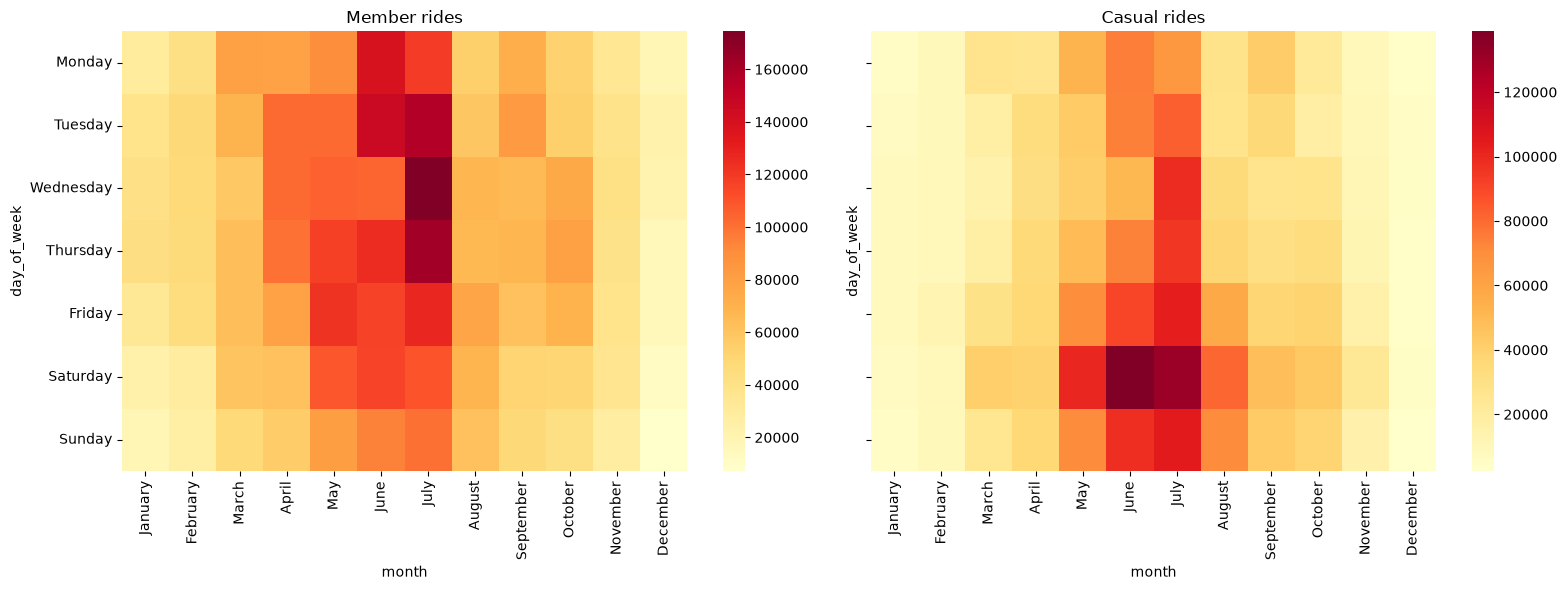

In [104]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, rider_type in zip(axes, ['member', 'casual']):
    subset = df[df['member_casual'] == rider_type]
    pivot = subset.pivot_table(index='day_of_week', columns='month', 
                                 values='ride_id', aggfunc='count')
    pivot = pivot.reindex(index=day_order, columns=month_order)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=False)
    ax.set_title(f'{rider_type.capitalize()} rides')

plt.tight_layout()
plt.show()

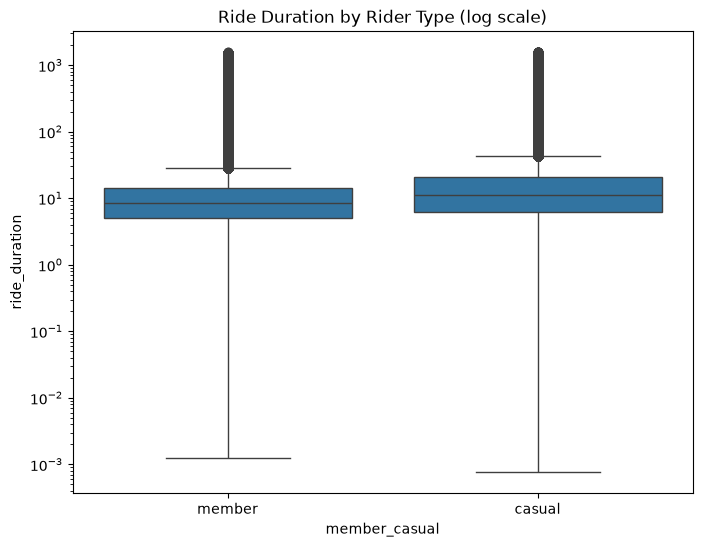

In [105]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='member_casual', y='ride_duration', ax=ax)
ax.set_yscale('log')
ax.set_title('Ride Duration by Rider Type (log scale)')
plt.show()

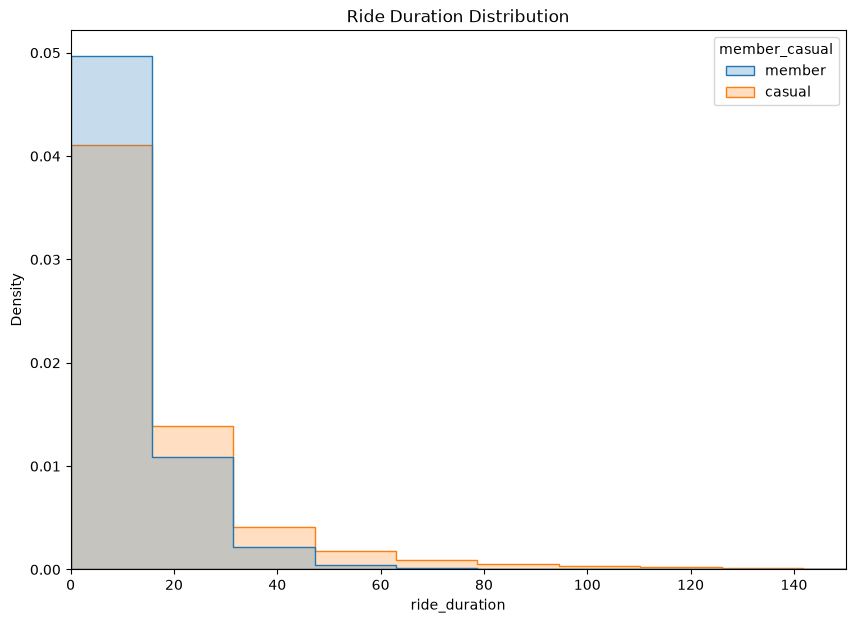

In [106]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.histplot(data=df, x='ride_duration', hue='member_casual', 
             bins=100, element='step', stat='density', common_norm=False, ax=ax)
ax.set_xlim(0, 150)
ax.set_title('Ride Duration Distribution')
plt.show()

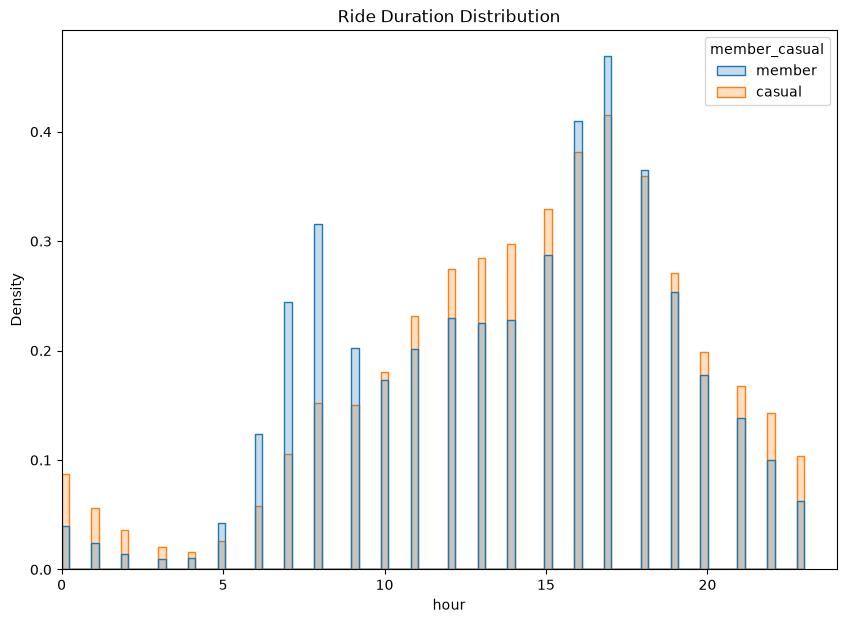

In [107]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.histplot(data=df, x='hour', hue='member_casual', 
             bins=100, element='step', stat='density', common_norm=False, ax=ax)
ax.set_xlim(0, 24)
ax.set_title('Ride Duration Distribution')
plt.show()

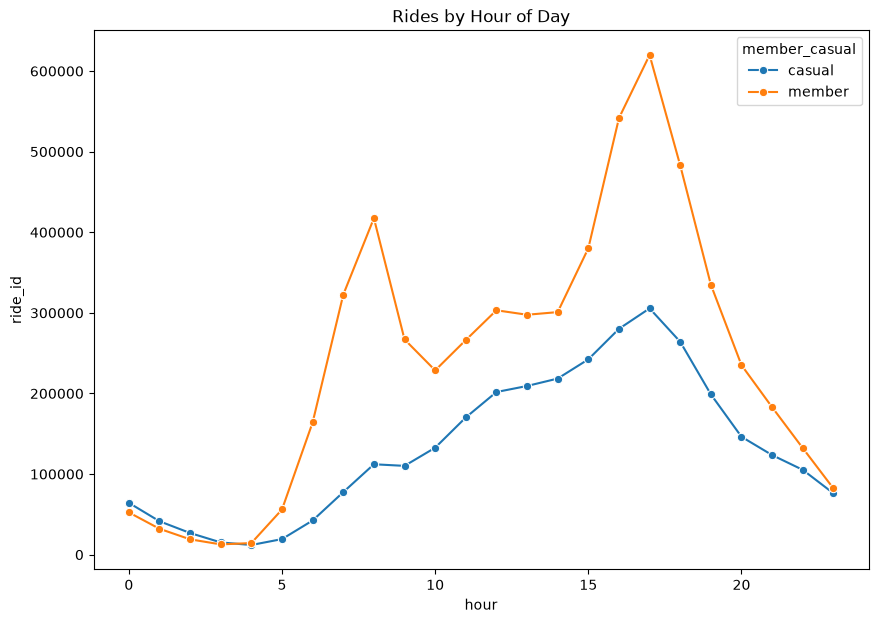

In [108]:
hourly = df.groupby(['hour', 'member_casual'])['ride_id'].count().reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
sns.lineplot(data=hourly, x='hour', y='ride_id', hue='member_casual', marker='o', ax=ax)
ax.set_title('Rides by Hour of Day')
plt.show()

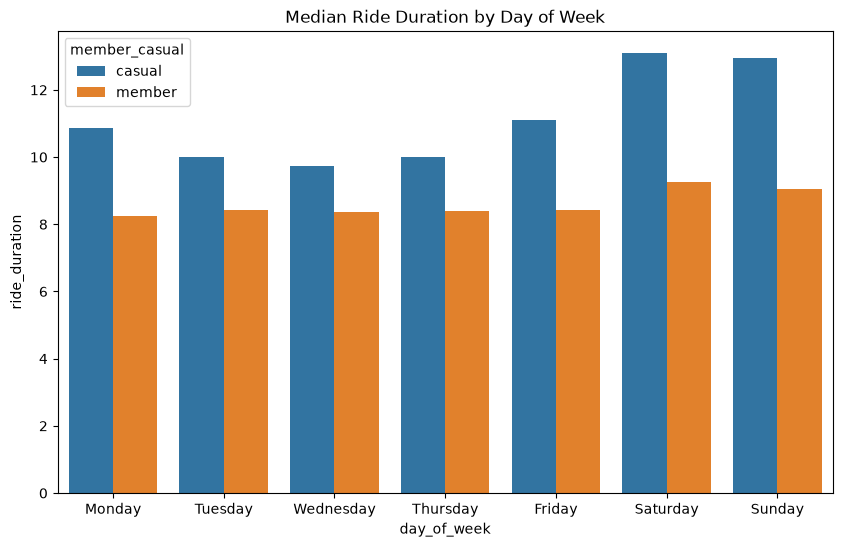

In [109]:
avg_by_day = df.groupby(['day_of_week', 'member_casual'])['ride_duration'].median().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=avg_by_day, x='day_of_week', y='ride_duration', 
            hue='member_casual', order=day_order, ax=ax)
ax.set_title('Median Ride Duration by Day of Week')
plt.show()

In [110]:
df['day_of_week'] = df['started_at'].dt.day_name()
df['month'] = df['started_at'].dt.month_name()
df['hour'] = df['started_at'].dt.hour
df['weekend'] = df['started_at'].dt.dayofweek >= 5
df['overnighter'] = df['started_at'].dt.dayofweek != df['ended_at'].dt.dayofweek

In [111]:
df['ride_id'].duplicated().sum()

np.int64(35)

In [112]:
dupl = df[df['ride_id'].duplicated(keep=False)].sort_values('ride_id')


In [113]:
dupl.duplicated().sum()

np.int64(0)

In [114]:
dupl.groupby('ride_id').size().value_counts()

2    35
Name: count, dtype: int64

In [115]:
dupl.groupby('ride_id').nunique()

,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file,ride_duration,day_of_week,hour,month,weekend,overnighter
ride_id,,,,,,,,,,,,,,,,,,,
03C5375398BE0649,1,1,1,0,0,1,1,1,1,1,1,1,2,1,1,1,1,1,1
0612B2A21BA5E988,1,1,1,1,1,0,0,1,1,0,0,1,2,1,1,1,1,1,1
10117825A92C182D,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1
15521787039F37E5,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1
1DB04E901469FB2F,1,1,1,1,1,0,0,1,1,1,1,1,2,1,1,1,1,1,1
2034B29BDC8E2559,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1
2038F30519CBC7E5,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1
3767A2E3310A5B0B,1,1,1,1,1,0,0,1,1,0,0,1,2,1,1,1,1,1,1
3D8B4B1B10438A9F,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1


In [116]:
dupl.groupby('ride_id')['ended_at'].agg(list)

ride_id
03C5375398BE0649    [2026-05-01 00:04:48.512000, 2026-05-01 00:04:...
0612B2A21BA5E988    [2026-05-01 16:56:08.148000, 2026-05-01 16:56:...
10117825A92C182D    [2026-05-01 00:01:51.860000, 2026-05-01 00:01:...
15521787039F37E5    [2026-05-01 00:05:45.575000, 2026-05-01 00:05:...
1DB04E901469FB2F    [2026-05-01 00:11:09.709000, 2026-05-01 00:11:...
2034B29BDC8E2559    [2026-05-01 13:30:44.841000, 2026-05-01 13:30:...
2038F30519CBC7E5    [2026-05-01 00:03:35.194000, 2026-05-01 00:03:...
3767A2E3310A5B0B    [2026-05-01 01:24:41.485000, 2026-05-01 01:24:...
3D8B4B1B10438A9F    [2026-05-01 00:03:08.550000, 2026-05-01 00:03:...
41E2750A57535CF7    [2026-05-01 00:12:39.854000, 2026-05-01 00:12:...
437C637BFCE893DE    [2026-05-01 15:17:38.941000, 2026-05-01 15:17:...
47B00C2CFA51BED8    [2026-05-01 00:00:40.360000, 2026-05-01 00:00:...
4B93DFFDA6B08DE5    [2026-05-01 00:04:42.964000, 2026-05-01 00:04:...
4EBCC6DF233878B6    [2026-05-01 00:02:42.981000, 2026-05-01 00:02:...
5232F2CB3D29

In [117]:
df = df.drop_duplicates(subset='ride_id', keep='first')

In [118]:
df['ride_id'].duplicated().sum()

np.int64(0)

In [119]:
pd.set_option('display.max_rows', 100)

In [120]:
df.isna().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1876300
start_station_id      1876300
end_station_name      1965418
end_station_id        1965418
start_lat                   0
start_lng                   0
end_lat                  8588
end_lng                  8588
member_casual               0
source_file                 0
ride_duration               0
day_of_week                 0
hour                        0
month                       0
weekend                     0
overnighter                 0
dtype: int64

In [121]:
df_export = df.drop(columns=['source_file'])

In [122]:
before = len(df_export)
df_export = df_export[df_export['started_at'].dt.year >= 2025]
after = len(df_export)
print(f'removed {before - after} rows started before 2025')

removed 53 rows started before 2025


done with cleaning and merge, will create multiple tables to play with schemas in talbeau...

In [123]:
start_stations = df_export[['start_station_id', 'start_station_name', 'start_lat', 'start_lng']].rename(
    columns={'start_station_id': 'station_id', 'start_station_name': 'station_name',
             'start_lat': 'lat', 'start_lng': 'lng'}
)

In [124]:
end_stations = df_export[['end_station_id', 'end_station_name', 'end_lat', 'end_lng']].rename(
    columns={'end_station_id': 'station_id', 'end_station_name': 'station_name',
             'end_lat': 'lat', 'end_lng': 'lng'}
)

In [125]:
all_stations = pd.concat([start_stations,end_stations], ignore_index=True)

In [126]:
all_stations = all_stations.dropna(subset=['station_id'])

In [127]:
dim_stations = (
    all_stations.groupby('station_id')
    .agg(
        station_name=('station_name', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        lat=('lat','median'),
        lng=('lng', 'median')
    )
    .reset_index()
)

In [128]:
dim_stations['lat_round'] = dim_stations['lat'].round(4)
dim_stations['lng_round'] = dim_stations['lng'].round(4)

In [129]:
dupe_check = dim_stations.groupby(['lat_round', 'lng_round'])['station_id'].transform('count')
print("Station IDs sharing coordinates with another:", (dupe_check > 1).sum())


Station IDs sharing coordinates with another: 3092


In [130]:

dim_stations[dupe_check > 1].sort_values(['lat_round', 'lng_round']).tail(20)

,station_id,station_name,lat,lng,lat_round,lng_round
1012,599,Valli Produce - Evanston Plaza,42.04,-87.70,42.04,-87.70
2035,CHI00977,Valli Produce - Evanston Plaza,42.04,-87.70,42.04,-87.70
1010,596,Benson Ave & Church St,42.05,-87.68,42.05,-87.68
1803,CHI00737,Benson Ave & Church St,42.05,-87.68,42.05,-87.68
1013,600,Dodge Ave & Church St,42.05,-87.70,42.05,-87.70
1807,CHI00741,Dodge Ave & Church St,42.05,-87.70,42.05,-87.70
3010,CHI02043,Chicago Ave & Sheridan Rd,42.05,-87.68,42.05,-87.68
3372,E008,Chicago Ave & Sheridan Rd,42.05,-87.68,42.05,-87.68
1015,605,University Library (NU),42.05,-87.67,42.05,-87.67
2235,CHI01208,University Library (NU),42.05,-87.67,42.05,-87.67


In [131]:
print(dim_stations.shape)
dim_stations.head(10)

(3678, 6)


,station_id,station_name,lat,lng,lat_round,lng_round
0,24321,Oconto Ave & Belmont Ave,41.94,-87.81,41.94,-87.81
1,CHI02331,Franklin St & Randolph St,41.88,-87.64,41.88,-87.64
2,(ARCHIVE)CHI02077,Clark St & Lake St,41.89,-87.63,41.89,-87.63
3,(ARCHIVE)CHI02078,Franklin St & Monroe St,41.88,-87.64,41.88,-87.64
4,(ARCHIVE)CHI02079,Daley Center Plaza,41.88,-87.63,41.88,-87.63
5,000-CHI01831,Kedzie Ave & Jackson Blvd,41.88,-87.71,41.88,-87.71
6,1011,Public Rack - Fullerton Ave & Narragansett Ave,41.92,-87.79,41.92,-87.79
7,1012,Public Rack - Langley Ave & 49th St,41.81,-87.61,41.81,-87.61
8,1014,Public Rack - Richmond St & Thorndale Ave,41.99,-87.70,41.99,-87.70
9,1015,Public Rack - Peterson Ave & Drake Ave,41.99,-87.72,41.99,-87.72


In [132]:
dim_stations['station_name_clean'] = (
    dim_stations['station_name']
    .str.replace(r'^Public Rack - ', '', regex=True)
    .str.replace(r'\*$', '', regex=True)
    .str.strip()
)

In [133]:
canonical = (
    dim_stations.groupby(['lat_round', 'lng_round'])['station_name_clean']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={'station_name_clean': 'canonical_station_name'})
)

dim_stations = dim_stations.merge(canonical, on=['lat_round', 'lng_round'], how='left')

In [134]:
dim_stations['station_name'].duplicated().sum()

np.int64(1608)

In [135]:
dim_stations['station_name_clean'].isna().sum()

np.int64(0)

In [136]:
# How many distinct real stations do you actually have, by name?
print("Unique station_ids:", dim_stations['station_id'].nunique())
print("Unique cleaned names:", dim_stations['station_name_clean'].nunique())

Unique station_ids: 3678
Unique cleaned names: 2022


In [137]:
canonical_by_name = (
    dim_stations.dropna(subset=['station_name_clean'])
    .groupby('station_name_clean')
    .agg(
        canonical_lat=('lat', 'median'),
        canonical_lng=('lng', 'median')
    )
    .reset_index()
)

dim_stations = dim_stations.merge(canonical_by_name, on='station_name_clean', how='left')

In [138]:
# For any station missing a name, fall back to its own id/coords so nothing gets dropped
dim_stations['canonical_lat'] = dim_stations['canonical_lat'].fillna(dim_stations['lat'])
dim_stations['canonical_lng'] = dim_stations['canonical_lng'].fillna(dim_stations['lng'])

In [139]:
dim_stations[['station_id', 'station_name_clean', 'lat', 'lng', 'canonical_lat', 'canonical_lng']].head(20)

,station_id,station_name_clean,lat,lng,canonical_lat,canonical_lng
0,24321,Oconto Ave & Belmont Ave,41.94,-87.81,41.94,-87.81
1,CHI02331,Franklin St & Randolph St,41.88,-87.64,41.88,-87.64
2,(ARCHIVE)CHI02077,Clark St & Lake St,41.89,-87.63,41.89,-87.63
3,(ARCHIVE)CHI02078,Franklin St & Monroe St,41.88,-87.64,41.88,-87.64
4,(ARCHIVE)CHI02079,Daley Center Plaza,41.88,-87.63,41.88,-87.63
5,000-CHI01831,Kedzie Ave & Jackson Blvd,41.88,-87.71,41.88,-87.71
6,1011,Fullerton Ave & Narragansett Ave,41.92,-87.79,41.92,-87.79
7,1012,Langley Ave & 49th St,41.81,-87.61,41.81,-87.61
8,1014,Richmond St & Thorndale Ave,41.99,-87.70,41.99,-87.70
9,1015,Peterson Ave & Drake Ave,41.99,-87.72,41.99,-87.72


In [140]:
dim_stations['station_name_clean'] = (
    dim_stations['station_name_clean']
    .str.replace(r'\s*Corral$', '', regex=True)
    .str.strip()
)

In [141]:
dim_stations[dim_stations['station_name_clean'].str.contains('Wells St & Randolph', na=False)]

,station_id,station_name,lat,lng,lat_round,lng_round,station_name_clean,canonical_station_name,canonical_lat,canonical_lng
1334,CHI00266,Wells St & Randolph St,41.88,-87.63,41.88,-87.63,Wells St & Randolph St,Wells St & Randolph St,41.88,-87.63
2520,CHI01540,Wells St & Randolph St Corral,41.88,-87.63,41.88,-87.63,Wells St & Randolph St,Wells St & Randolph St Corral,41.88,-87.63
3360,Corral 18,Wells St & Randolph St Corral,41.88,-87.63,41.88,-87.63,Wells St & Randolph St,Wells St & Randolph St Corral,41.88,-87.63
3528,TA1305000030,Wells St & Randolph St,41.88,-87.63,41.88,-87.63,Wells St & Randolph St,Wells St & Randolph St,41.88,-87.63


In [142]:
min_date = df_export['started_at'].dt.date.min()
max_date = df_export['ended_at'].dt.date.max()

dim_date = pd.DataFrame({'date': pd.date_range(min_date, max_date, freq='D')})


In [143]:
dim_date['date_key'] = dim_date['date'].dt.strftime('%Y%m%d').astype(int)
dim_date['day_of_week'] = dim_date['date'].dt.day_name()
dim_date['month'] = dim_date['date'].dt.month_name()
dim_date['year'] = dim_date['date'].dt.year
dim_date['weekend'] = dim_date['date'].dt.dayofweek >= 5
dim_date['season'] = dim_date['date'].dt.month.map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Fall',10:'Fall',11:'Fall'
})

In [144]:
dim_date.head()

,date,date_key,day_of_week,month,year,weekend,season
0,2025-01-01,20250101,Wednesday,January,2025,False,Winter
1,2025-01-02,20250102,Thursday,January,2025,False,Winter
2,2025-01-03,20250103,Friday,January,2025,False,Winter
3,2025-01-04,20250104,Saturday,January,2025,True,Winter
4,2025-01-05,20250105,Sunday,January,2025,True,Winter


In [145]:
fact_rides = df_export[[
    'ride_id', 'started_at', 'ended_at', 'ride_duration',
    'start_station_id', 'end_station_id',
    'member_casual', 'rideable_type'
]].copy()

In [146]:
fact_rides['date_key'] = fact_rides['started_at'].dt.strftime('%Y%m%d').astype(int)
fact_rides['hour'] = fact_rides['started_at'].dt.hour

In [147]:
fact_rides.head()

,ride_id,started_at,ended_at,ride_duration,start_station_id,end_station_id,member_casual,rideable_type,date_key,hour
0,7569BC890583FCD7,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,13.96,KA1503000072,TA1306000029,member,classic_bike,20250121,17
1,013609308856B7FC,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,5.07,TA1309000061,TA1308000019,member,electric_bike,20250111,15
2,EACACD3CE0607C0D,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,11.59,13235,13278,member,classic_bike,20250102,15
3,EAA2485BA64710D3,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,3.57,13235,13071,member,classic_bike,20250123,8
4,7F8BE2471C7F746B,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,2.57,13235,13071,member,electric_bike,20250116,8


In [ ]:
STAR_DIR = "../04_merged_data/star_schema"
os.makedirs(STAR_DIR, exist_ok=True)

fact_rides.to_csv(f"{STAR_DIR}/fact_rides.csv", index=False)
dim_stations.to_csv(f"{STAR_DIR}/dim_stations.csv", index=False)
dim_date.to_csv(f"{STAR_DIR}/dim_date.csv", index=False)

In [153]:
print("fact_rides:", fact_rides.shape)
print("dim_stations:", dim_stations.shape)
print("dim_date:", dim_date.shape)

fact_rides: (8942737, 10)
dim_stations: (3678, 10)
dim_date: (577, 7)


In [154]:
dim_stations.head()

,station_id,station_name,lat,lng,lat_round,lng_round,station_name_clean,canonical_station_name,canonical_lat,canonical_lng
0,24321,Oconto Ave & Belmont Ave,41.94,-87.81,41.94,-87.81,Oconto Ave & Belmont Ave,Oconto Ave & Belmont Ave,41.94,-87.81
1,CHI02331,Franklin St & Randolph St,41.88,-87.64,41.88,-87.64,Franklin St & Randolph St,Franklin St & Randolph St,41.88,-87.64
2,(ARCHIVE)CHI02077,Clark St & Lake St,41.89,-87.63,41.89,-87.63,Clark St & Lake St,Clark St & Lake St,41.89,-87.63
3,(ARCHIVE)CHI02078,Franklin St & Monroe St,41.88,-87.64,41.88,-87.64,Franklin St & Monroe St,Franklin St & Monroe St,41.88,-87.64
4,(ARCHIVE)CHI02079,Daley Center Plaza,41.88,-87.63,41.88,-87.63,Daley Center Plaza,Daley Center Plaza,41.88,-87.63


In [155]:
(df_export.started_at.dt.year < 2025).sum()

np.int64(0)